In [42]:
#This notebook analyzes warm data noise waveforms to produce:
# 1) Event Display
# 2) Average value per waveform
# 3) RMS value per waveform
# 4) Correlation matrix between channels
# 5) Power Spectrum per channel

In [12]:
from Analyzer import Analyzer
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt

In [7]:
Waveform_File_Path = '/home/matt/Documents/Research/ICEBERG/Data/Sept_2025/Waveforms_Run_16060.root'

In [20]:
infile = uproot.open(Waveform_File_Path)
key = infile.keys()[0]
H, xedges, yedges = infile[key].to_numpy()

print(H.shape)
print(xedges.shape)
print(yedges.shape)

(1280, 2128)
(1281,)
(2129,)


In [ ]:
def Plot2DWaveform(H,xedges,yedges):

        fig2,ax2 = plt.subplots(1,figsize=(20,10))
        pc2 = ax2.pcolorfast(xedges,yedges,H.T)

        plt.show()

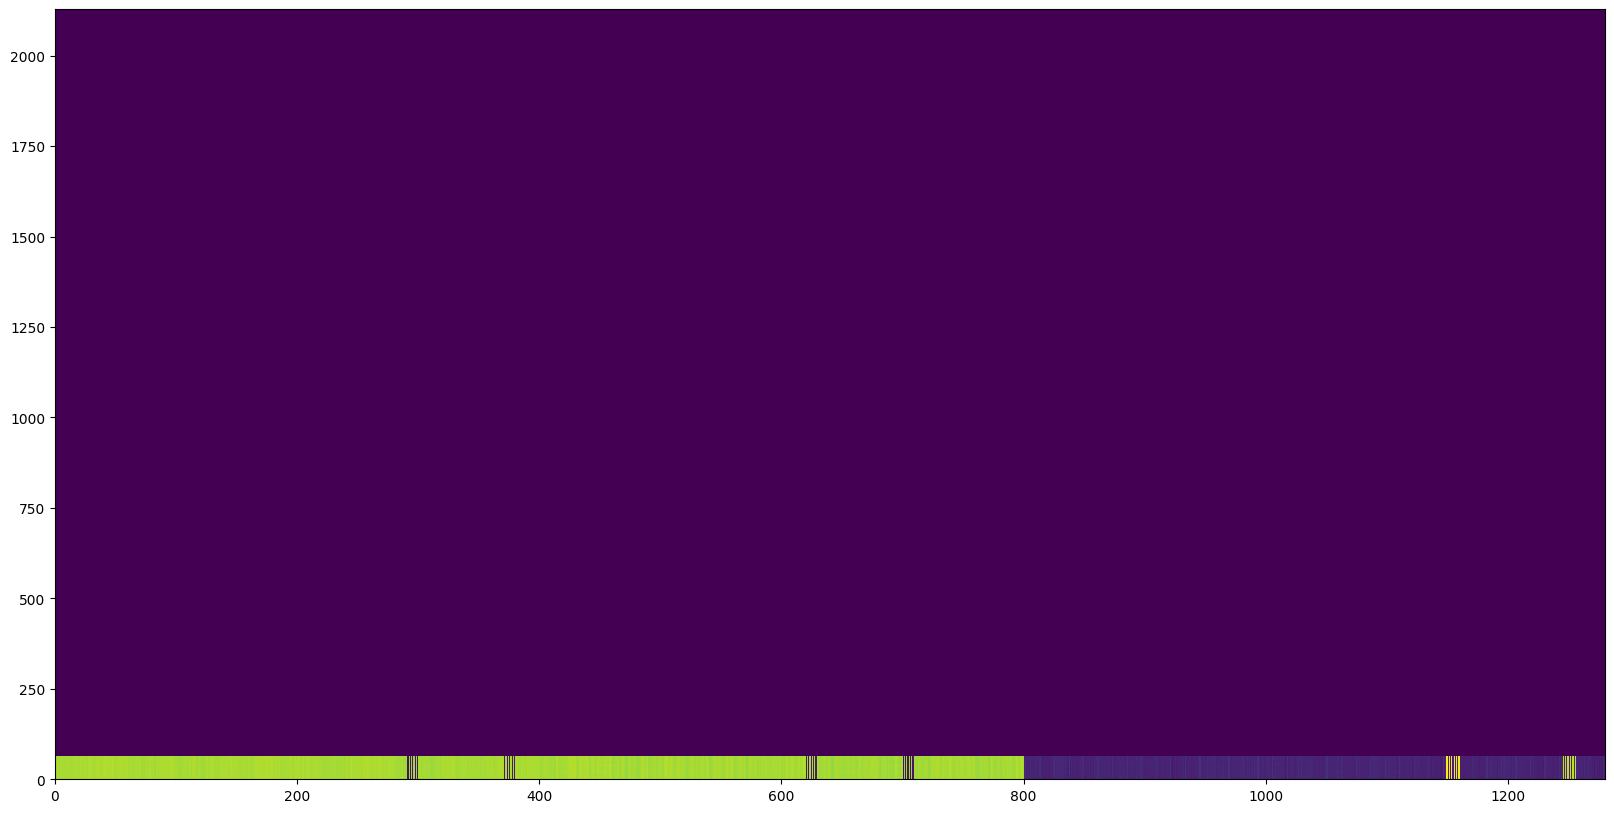

In [10]:
Plot2DWaveform(H,xedges,yedges)

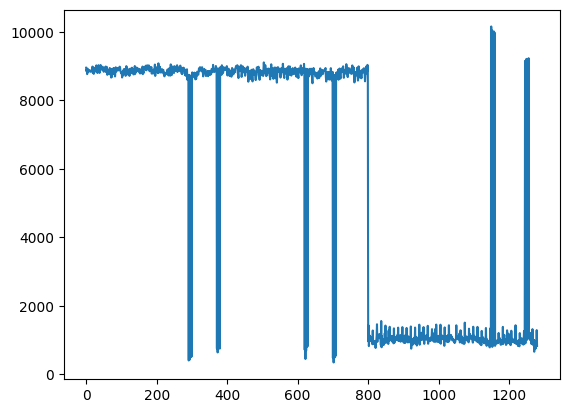

In [ ]:
plt.figure()
plt.plot(H[:,0]) #first time tick for all channels

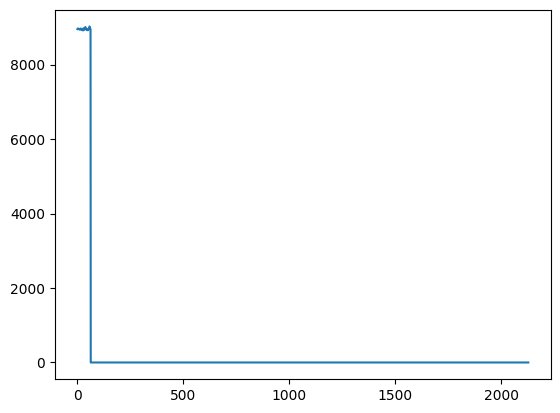

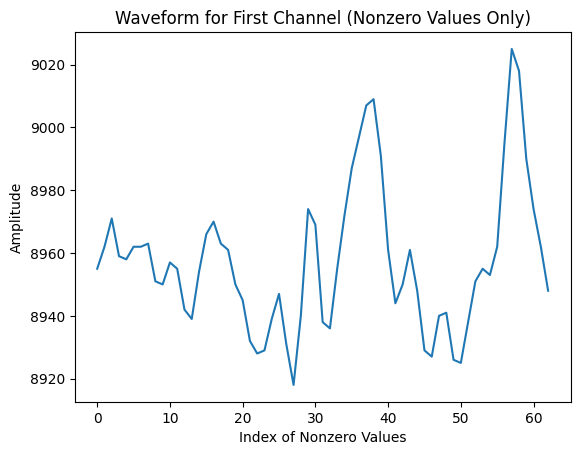

63


In [ ]:
plt.figure()
plt.plot(H[0]) #first channel for all time ticks

#For the waveform on the first channel.
#Plot the waveform for all nonzero values.

nonzero_indices = np.nonzero(H[0])[0]
plt.figure()
plt.plot(nonzero_indices, H[0][nonzero_indices])
plt.xlabel('Index of Nonzero Values')
plt.ylabel('Amplitude')
plt.title('Waveform for First Channel (Nonzero Values Only)')
plt.show()

print(len(nonzero_indices))

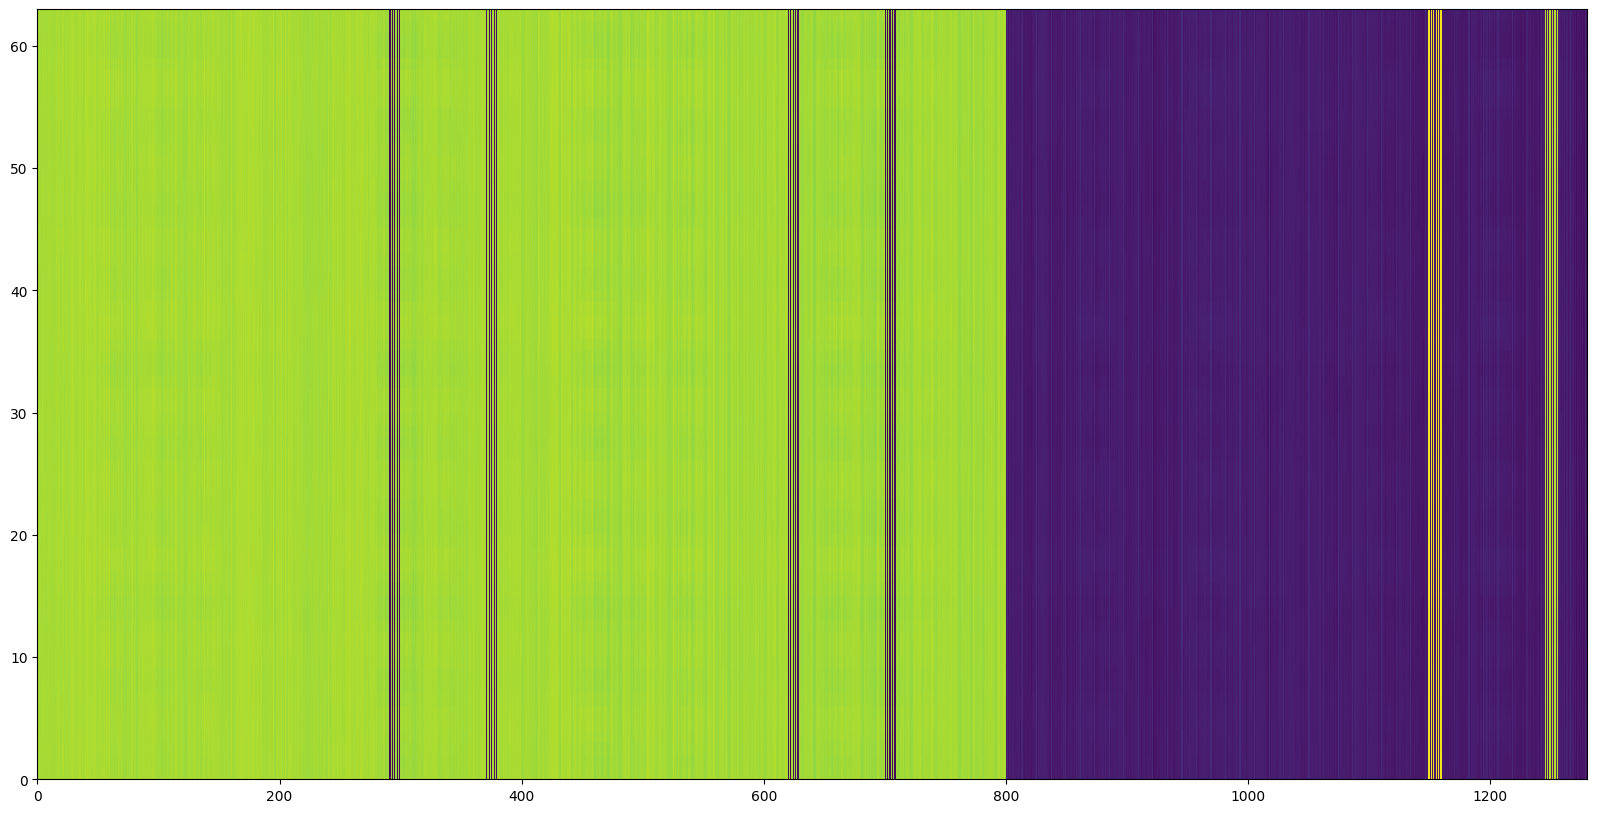

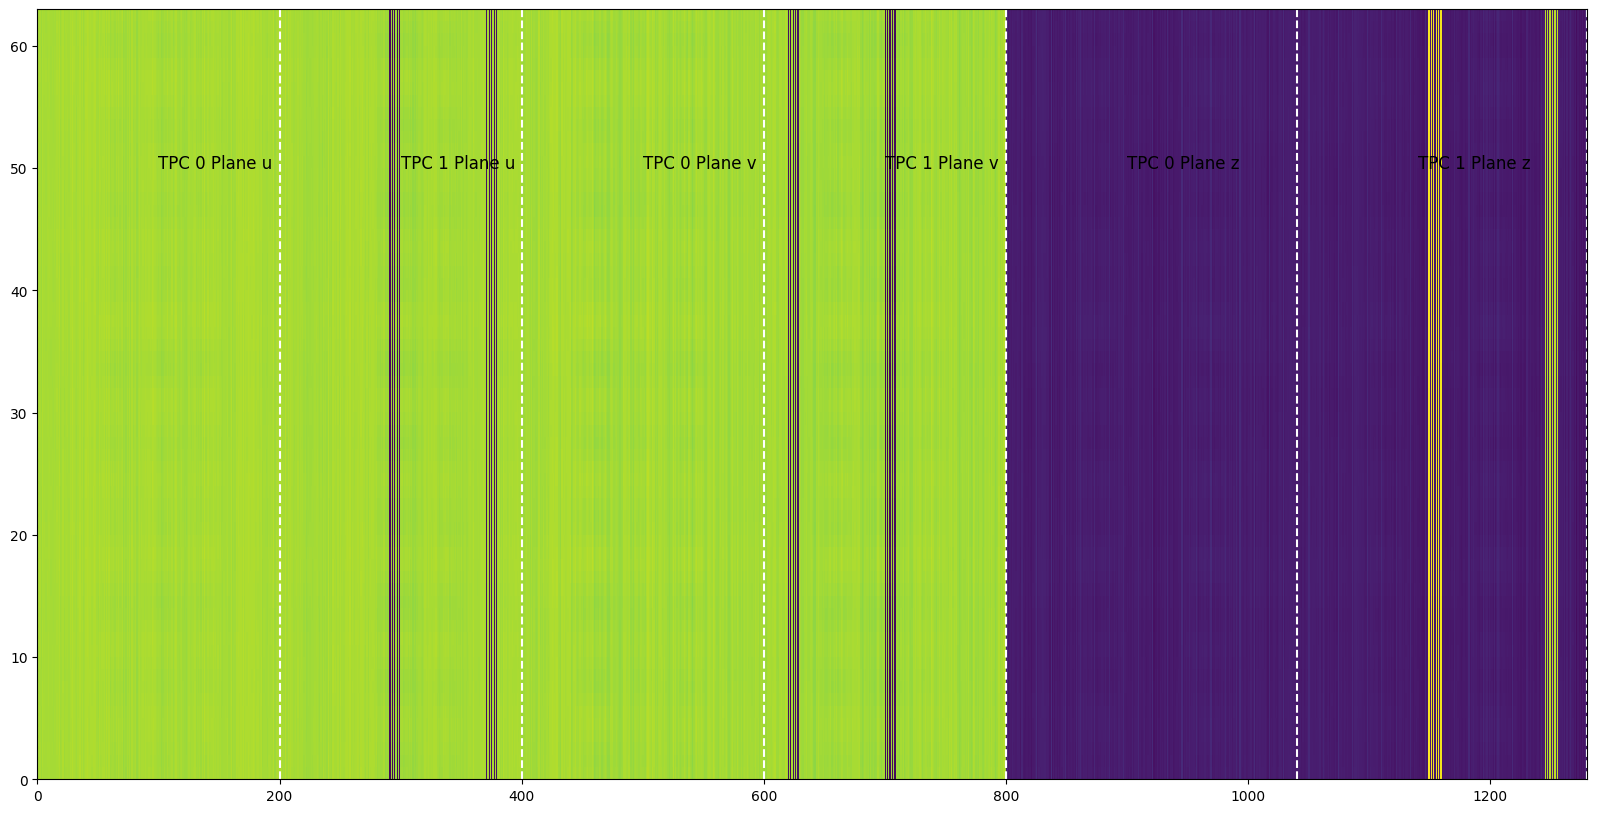

In [ ]:
#Redo 2D plot, but only for the first 63 indices for each channel
H_reduced = H[:,:63]  # Keep only the first 63 time ticks   
#Also need to modify xedges and yedges accordingly
xedges_reduced = xedges
yedges_reduced = yedges[:64]  # 63 bins require 64 edges
Plot2DWaveform(H_reduced, xedges_reduced, yedges_reduced)

#Redo 2D plot, but draw dotted lines to show each plane. Key given:
        #SortedArray[0][0][0:200] = MegaArray[0:200]     #TPC 0 Plane u
        #SortedArray[1][0][0:200] = MegaArray[200:400]   #TPC 1 Plane u
        #SortedArray[0][1][0:200] = MegaArray[400:600]   #TPC 0 Plane v
        #SortedArray[1][1][0:200] = MegaArray[600:800]   #TPC 1 Plane v
        #SortedArray[0][2]        = MegaArray[800:1040]  #TPC 0 Plane z
        #SortedArray[1][2]        = MegaArray[1040:1280] #TPC 1 Plane z
#We also label with text each region

def Plot2DWaveformWithLines(H,xedges,yedges):
    
        fig2,ax2 = plt.subplots(1,figsize=(20,10))
        pc2 = ax2.pcolorfast(xedges,yedges,H.T)

        #Draw dotted lines
        for line in [0, 200, 400, 600, 800, 1040, 1280]:
            ax2.axvline(x=line, color='w', linestyle='--')
        #Add text labels
        ax2.text(100, 50, 'TPC 0 Plane u', color='k', fontsize=12)
        ax2.text(300, 50, 'TPC 1 Plane u', color='k', fontsize=12)
        ax2.text(500, 50, 'TPC 0 Plane v', color='k', fontsize=12)
        ax2.text(700, 50, 'TPC 1 Plane v', color='k', fontsize=12)
        ax2.text(900, 50, 'TPC 0 Plane z', color='k', fontsize=12)
        ax2.text(1140, 50, 'TPC 1 Plane z', color='k', fontsize=12)

        plt.show()

Plot2DWaveformWithLines(H_reduced, xedges_reduced, yedges_reduced)

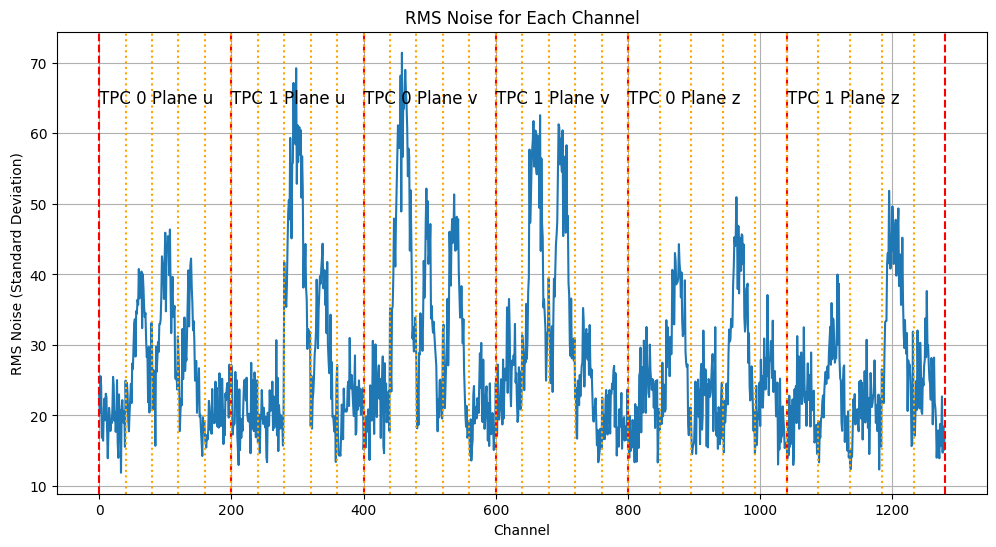

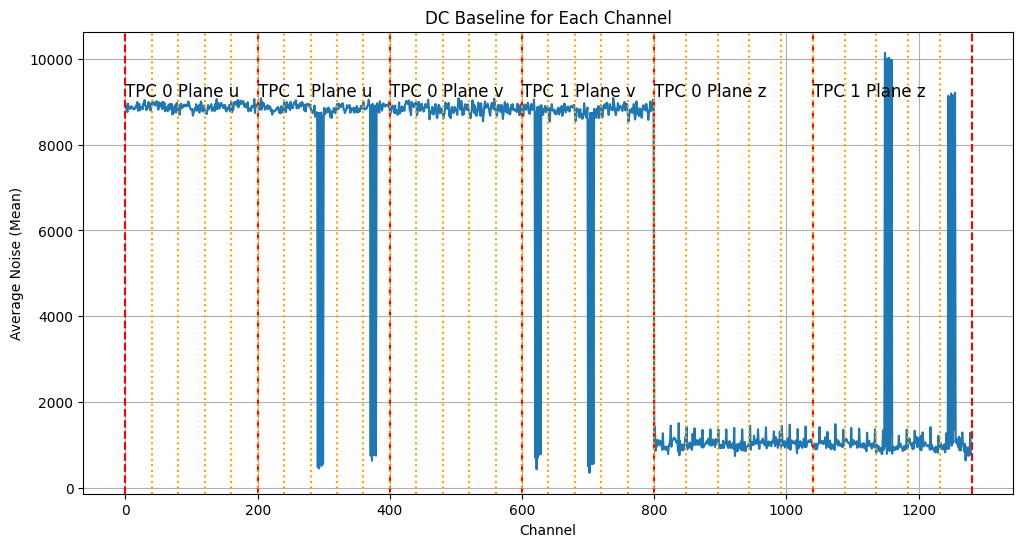

In [43]:
#Make a plot of the rms noise for each channel, defined as the standard deviation of the waveform for that channel
#Make sure to use only nonzero values for each channel
rms_noise = []
for channel in range(H.shape[0]):
    nonzero_values = H[channel][H[channel] != 0]
    if len(nonzero_values) > 0:
        rms = np.std(nonzero_values)
    else:
        rms = 0
    rms_noise.append(rms)

plt.figure(figsize=(12,6))
plt.plot(rms_noise, linestyle='-')
plt.xlabel('Channel')
plt.ylabel('RMS Noise (Standard Deviation)')
plt.title('RMS Noise for Each Channel')
plt.grid()

#include vertical lines to show each plane
for line in [0, 200, 400, 600, 800, 1040, 1280]:
    plt.axvline(x=line, color='r', linestyle='--')
for tick in np.concatenate((40*(np.arange(19)+1),48*np.arange(10)+800)):
    plt.axvline(x=tick, color="orange", linestyle=':')
#Add text labels
plt.text(0, max(rms_noise)*0.9, 'TPC 0 Plane u', color='k', fontsize=12)
plt.text(200, max(rms_noise)*0.9, 'TPC 1 Plane u', color='k', fontsize=12)
plt.text(400, max(rms_noise)*0.9, 'TPC 0 Plane v', color='k', fontsize=12)
plt.text(600, max(rms_noise)*0.9, 'TPC 1 Plane v', color='k', fontsize=12)
plt.text(800, max(rms_noise)*0.9, 'TPC 0 Plane z', color='k', fontsize=12)
plt.text(1040, max(rms_noise)*0.9, 'TPC 1 Plane z', color='k', fontsize=12)
plt.show()

#Also plot the average value for each channel, defined as the mean of the waveform (for nonzero values) for that channel
avg_noise = []
for channel in range(H.shape[0]):
    nonzero_values = H[channel][H[channel] != 0]
    if len(nonzero_values) > 0:
        avg = np.mean(nonzero_values)
    else:
        avg = 0
    avg_noise.append(avg)
plt.figure(figsize=(12,6))
plt.plot(avg_noise, linestyle='-')
plt.xlabel('Channel')
plt.ylabel('Average Noise (Mean)')
plt.title('DC Baseline for Each Channel')
plt.grid()
#Include vertical lines to show each plane
for line in [0, 200, 400, 600, 800, 1040, 1280]:
    plt.axvline(x=line, color='r', linestyle='--')
for tick in np.concatenate((40*(np.arange(19)+1),48*np.arange(10)+800)):
    plt.axvline(x=tick, color="orange", linestyle=':')
#Add text labels
plt.text(0, max(avg_noise)*0.9, 'TPC 0 Plane u', color='k', fontsize=12)
plt.text(200, max(avg_noise)*0.9, 'TPC 1 Plane u', color='k', fontsize=12)
plt.text(400, max(avg_noise)*0.9, 'TPC 0 Plane v', color='k', fontsize=12)
plt.text(600, max(avg_noise)*0.9, 'TPC 1 Plane v', color='k', fontsize=12)
plt.text(800, max(avg_noise)*0.9, 'TPC 0 Plane z', color='k', fontsize=12)
plt.text(1040, max(avg_noise)*0.9, 'TPC 1 Plane z', color='k', fontsize=12)
plt.show()      

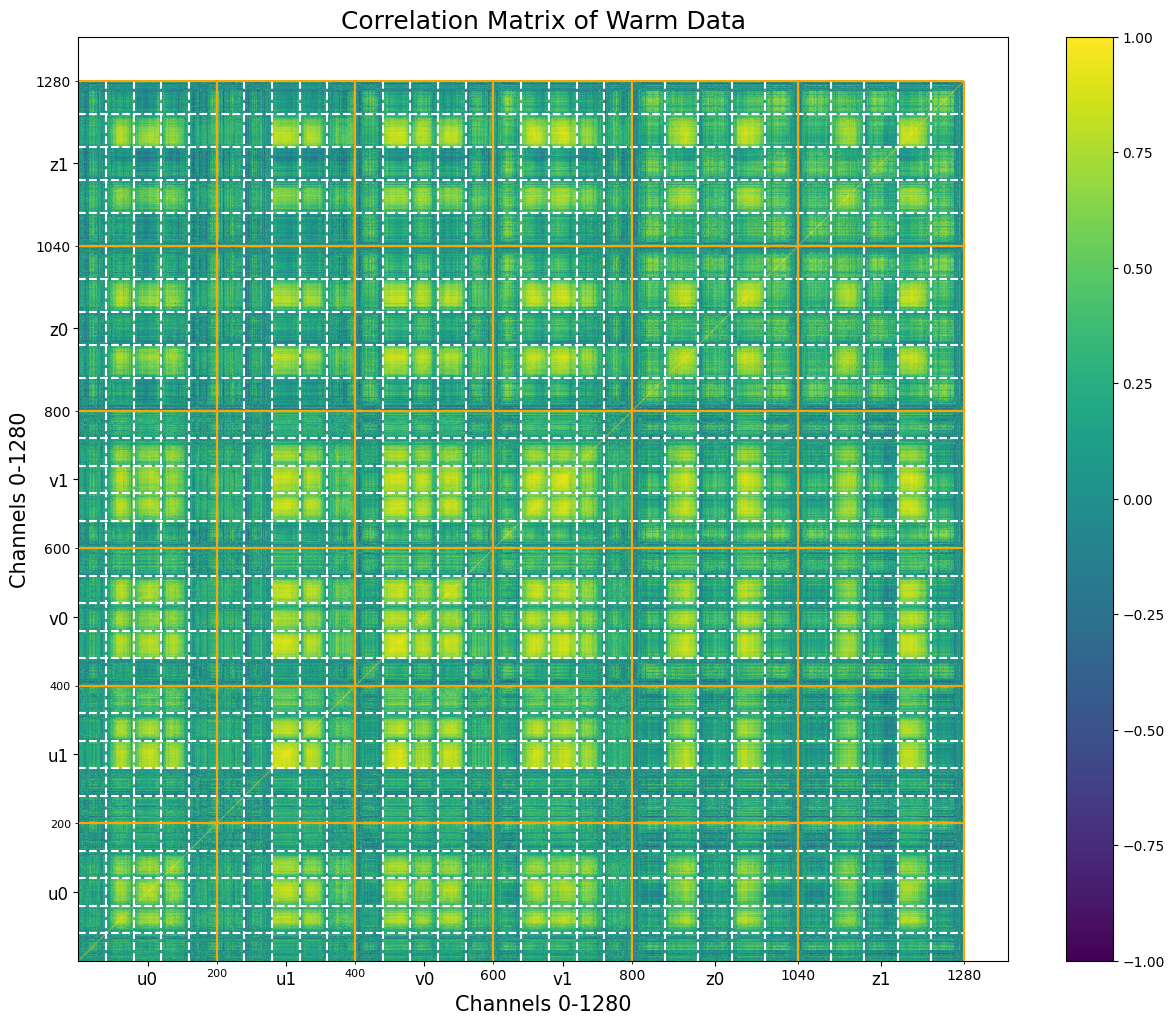

In [39]:
## Correlation
correlation_matrix = np.corrcoef(H_reduced)

def plotrCorr(CorrMatrix):
    import matplotlib.pyplot as plt
    import numpy as np
        
    lines = [200,400,600,800,1040,1280]
    linenames = ['200','400','600','800','1040','1280']
    ticks = np.concatenate((40*(np.arange(19)+1),48*np.arange(10)+800))
    planeindexes = [100,300,500,700,920,1160]
    planenames = ['u0','u1','v0','v1','z0','z1']

    fig = plt.figure(figsize=(15,12))
    plt.title("Correlation Matrix of Warm Data",fontsize=18)
    plt.colorbar(plt.pcolormesh(np.arange(1280),np.arange(1280),CorrMatrix,shading='gouraud',vmin=-1,vmax=1))
    plt.vlines(ticks,0,1280,linestyles='dashed',colors='white')
    plt.hlines(ticks,0,1280,linestyles='dashed',colors='white')
    plt.vlines(lines,0,1280, colors="orange")
    plt.hlines(lines,0,1280, colors="orange")
    plt.xticks(lines,linenames,minor=True,fontsize=8)
    plt.yticks(lines,linenames,minor=True,fontsize=8)
    plt.xticks(planeindexes,planenames,minor=False,fontsize=12)
    plt.yticks(planeindexes,planenames,minor=False,fontsize=12)
    plt.ylabel('Channels 0-1280',fontsize=15)
    plt.xlabel('Channels 0-1280',fontsize=15)
    plt.pcolormesh(np.arange(1280),np.arange(1280),CorrMatrix,shading='gouraud',vmin=-1,vmax=1)
    plt.show()

plotrCorr(correlation_matrix)


/tmp/ipykernel_7123/1632082406.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('viridis')
/tmp/ipykernel_7123/1632082406.py:25: RuntimeWarning: divide by zero encountered in log10
  FFT = np.log10(FFT)


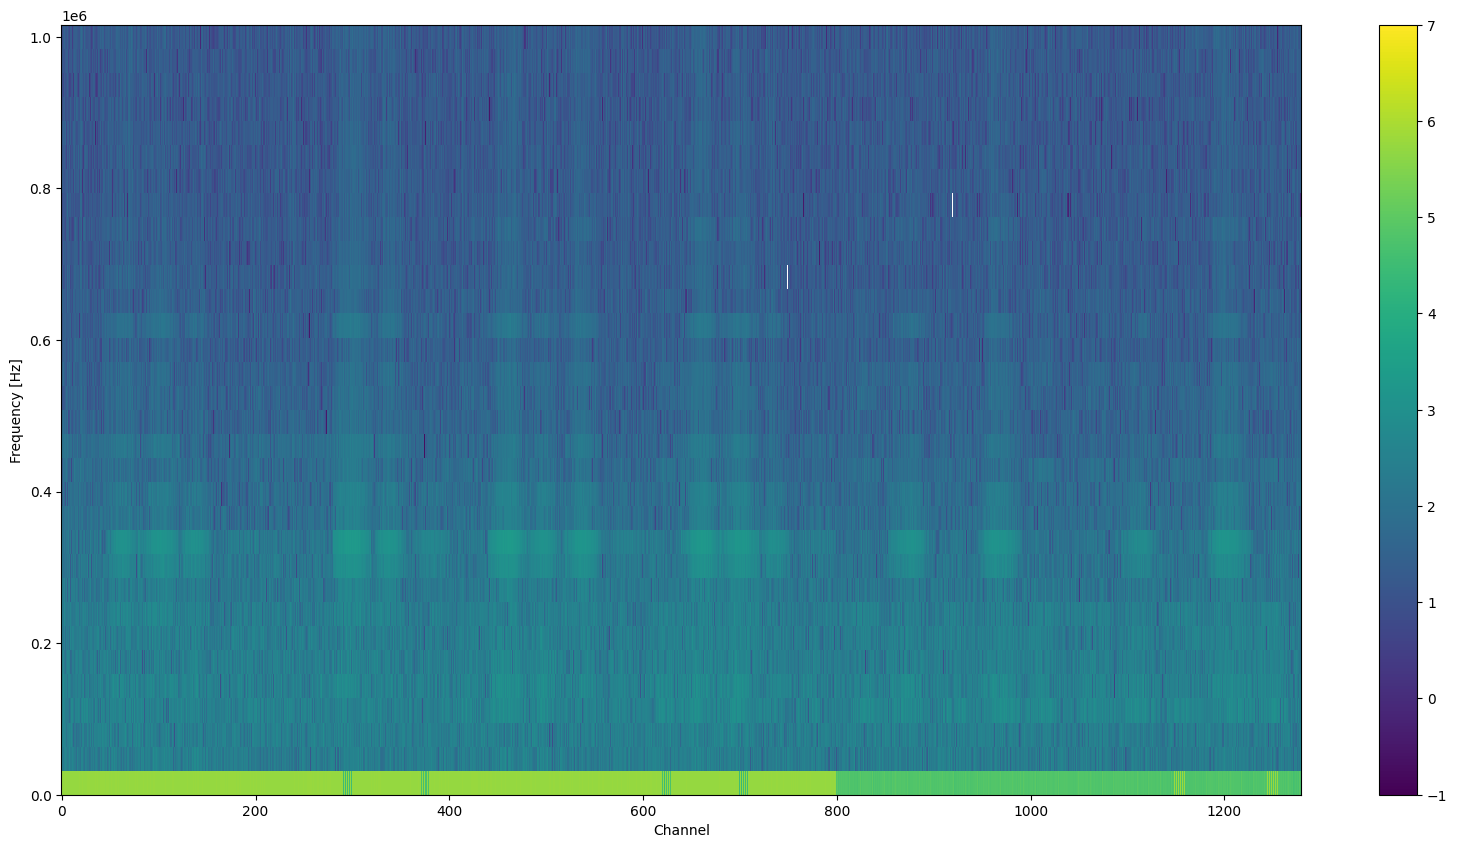

In [41]:
from Analyzer import Analyzer

FFT = np.abs(np.fft.rfft(H_reduced))
N=H_reduced.shape[1]
Seconds_Per_Timetick = 0.5e-6 #0.5 microseconds


def Plot2DFFT(FFT,vmin = -1, vmax = 7,log=True,N=63,Seconds_Per_Timetick=0.5e-6):
        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib as mpl

        freq = np.fft.rfftfreq(N,Seconds_Per_Timetick)
        freq_edges = Analyzer.CentersToEdges(freq,mode=1)
        channel_edges = Analyzer.CentersToEdges(np.arange(Analyzer.numchannels))

        fig,ax = plt.subplots(1,figsize=(20,10))
        #pc = ax.pcolorfast(channel_edges,freq_edges,FFT.T)

        cmap = mpl.cm.get_cmap('viridis')
        cmap.set_under('white')
        cmap.set_over('black')

        if log:
            FFT = np.log10(FFT)

        ax.pcolormesh(channel_edges,freq_edges,FFT.T,cmap = cmap,shading='flat',vmin = vmin, vmax = vmax) #default -1,7
        fig.colorbar(ax.pcolormesh(channel_edges,freq_edges,FFT.T,cmap = cmap,shading='flat',vmin = vmin, vmax = vmax) ) #default -1,7

        plt.xlabel('Channel')
        plt.ylabel('Frequency [Hz]')

        plt.show()

Plot2DFFT(FFT,vmin=-1,vmax=7,log=True,N=63,Seconds_Per_Timetick=0.5e-6)


In [ ]:
# A ~300kHz noise peak is visible on many channels
# The same channels which are all highly correlated

